In [1]:
from scipy.stats import *
from scipy import stats 
from typing import Union, List, Literal, TypeAlias
import numpy as np
import numpy.typing as npt
import pandas as pd
from functools import wraps, partial
from arch import arch_model
import matplotlib.pyplot as plt 

In [2]:
_ = pd.read_excel('hist.xlsx').to_numpy()
prices_usd = _[:, -2]

def return_array(prices): 
    rets = np.diff(prices) / prices[:-1]
    rets = np.array(rets, dtype='float64')
    return rets 

original_returns  = return_array(prices_usd)
bt_returns = original_returns[-50:]
returns_usd = original_returns[:-50]
returns_usd_scaled = returns_usd * 100

log_returns_usd = np.log(1 + returns_usd)
log_returns_usd_scaled = log_returns_usd * 100 

In [11]:
#simple garch testing 
garch_model = arch_model(log_returns_usd_scaled, vol='GARCH', p=1, q=1)
results_garch = garch_model.fit(disp='off')

conditional_volatility_garch = results_garch.conditional_volatility
residuals_garch = results_garch.resid
parameters_garch = results_garch.params

#Egarch testing 
egarch_model = arch_model(log_returns_usd_scaled, vol='EGARCH', p=1, o=0, q=1)
results_egarch = egarch_model.fit(disp='off')

conditional_volatility_egarch = results_egarch.conditional_volatility
residuals_egarch = results_egarch.resid
parameters_egarch = results_egarch.params

#student Egarch testing 
tegarch_model = arch_model(log_returns_usd_scaled, vol='EGARCH', p=1, o=0, q=1, dist='t')
results_tegarch = tegarch_model.fit(disp='off')

conditional_volatility_tegarch = results_tegarch.conditional_volatility
residuals_tegarch = results_tegarch.resid
parameters_tegarch = results_tegarch.params

print(conditional_volatility_egarch.shape, returns_usd_scaled.shape)
print(parameters_tegarch.nu)

#GJR GARCH model 
gjr_model = arch_model(log_returns_usd_scaled, vol='EGARCH', p=1, o=0, q=1, dist='t')
results_gjr = gjr_model.fit(disp='off')

conditional_volatility_gjr = results_gjr.conditional_volatility
residuals_gjr = results_gjr.resid
parameters_gjr = results_gjr.params

(1616,) (1616,)
3.838115728942505


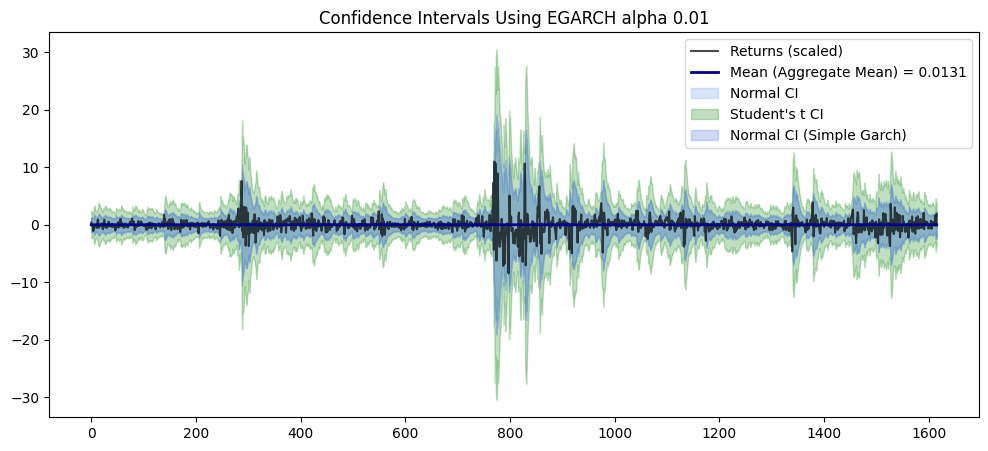

In [4]:
# Rolling parameters
window = 10 
alpha = 0.01  


rolling_mean = np.convolve(log_returns_usd_scaled, np.ones(window)/window, mode='valid')

#remove the beggining of the arrays

# simple rolling mean 
simple_rolling_mean = np.full_like(returns_usd_scaled, np.mean(log_returns_usd_scaled))

# Confidence intervals for Normal distribution
z = stats.norm.ppf(1 - alpha / 2)
ci_upper_norm = simple_rolling_mean + z * conditional_volatility_egarch
ci_lower_norm = simple_rolling_mean - z * conditional_volatility_egarch

# Confidence intervals for Student's t distribution
# Degrees of freedom can be set as per your model, here assumed 10 for example
df = parameters_tegarch.nu
t = stats.t.ppf(1 - alpha / 2, df)
ci_upper_t = simple_rolling_mean + t * conditional_volatility_tegarch
ci_lower_t = simple_rolling_mean - t * conditional_volatility_tegarch

#confidence intervals using Normal distribution for the case of simpel GARCH
z = stats.norm.ppf(1 - alpha / 2)
ci_upper_simple = simple_rolling_mean + z * conditional_volatility_garch
ci_lower_simple = simple_rolling_mean - z * conditional_volatility_garch

# Plot
plt.figure(figsize=(12, 5))
plt.plot(log_returns_usd_scaled, color='black', alpha=0.7, label='Returns (scaled)')
plt.plot(simple_rolling_mean, color='darkblue', label=f'Mean (Aggregate Mean) = {simple_rolling_mean[0]:.4f}', linewidth=2)
plt.fill_between(np.arange(len(returns_usd_scaled)), ci_lower_norm, ci_upper_norm, color='cornflowerblue', alpha=0.25, label='Normal CI')
plt.fill_between(np.arange(len(returns_usd_scaled)), ci_lower_t, ci_upper_t, color='green', alpha=0.25, label="Student's t CI")
plt.fill_between(np.arange(len(returns_usd_scaled)), ci_lower_simple, ci_upper_simple, color='royalblue', alpha=0.25, label='Normal CI (Simple Garch)')
plt.title(f'Confidence Intervals Using EGARCH alpha {alpha}')
plt.legend()
plt.show()

In [5]:
import plotly.graph_objects as go
import numpy as np

# Create figure
fig = go.Figure()

# Add the returns line (scaled)
fig.add_trace(go.Scatter(
    x=np.arange(len(log_returns_usd_scaled)),
    y=log_returns_usd_scaled,
    mode='lines',
    name='Returns (scaled)',
    line=dict(color='black', width=1),
    opacity=0.7
))

# Add the mean line
fig.add_trace(go.Scatter(
    x=np.arange(len(simple_rolling_mean)),
    y=simple_rolling_mean,
    mode='lines',
    name=f'Mean (Aggregate Mean) = {simple_rolling_mean[0]:.4f}',
    line=dict(color='darkblue', width=2)
))

# Add Normal CI (filled area)
fig.add_trace(go.Scatter(
    x=np.arange(len(returns_usd_scaled)),
    y=ci_upper_norm,
    mode='lines',
    line=dict(width=0),
    showlegend=False,
    hoverinfo='skip'
))
fig.add_trace(go.Scatter(
    x=np.arange(len(returns_usd_scaled)),
    y=ci_lower_norm,
    mode='lines',
    line=dict(width=0),
    fillcolor='rgba(100, 149, 237, 0.25)',  # cornflowerblue with alpha
    fill='tonexty',
    name='Normal CI',
    hoverinfo='skip'
))

# Add Student's t CI (filled area)
fig.add_trace(go.Scatter(
    x=np.arange(len(returns_usd_scaled)),
    y=ci_upper_t,
    mode='lines',
    line=dict(width=0),
    showlegend=False,
    hoverinfo='skip'
))
fig.add_trace(go.Scatter(
    x=np.arange(len(returns_usd_scaled)),
    y=ci_lower_t,
    mode='lines',
    line=dict(width=0),
    fillcolor='rgba(0, 128, 0, 0.25)',  # green with alpha
    fill='tonexty',
    name="Student's t CI",
    hoverinfo='skip'
))

# Add Normal CI (Simple Garch) (filled area)
fig.add_trace(go.Scatter(
    x=np.arange(len(returns_usd_scaled)),
    y=ci_upper_simple,
    mode='lines',
    line=dict(width=0),
    showlegend=False,
    hoverinfo='skip'
))
fig.add_trace(go.Scatter(
    x=np.arange(len(returns_usd_scaled)),
    y=ci_lower_simple,
    mode='lines',
    line=dict(width=0),
    fillcolor='rgba(65, 105, 225, 0.25)',  # royalblue with alpha
    fill='tonexty',
    name='Normal CI (Simple Garch)',
    hoverinfo='skip'
))

# Update layout
fig.update_layout(
    title=f'Confidence Intervals Using EGARCH alpha {alpha}',
    width=1200,
    height=500,
    hovermode='x unified',
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    )
)

fig.show()


In [6]:
a = (conditional_volatility_egarch - conditional_volatility_garch)/conditional_volatility_egarch
print(np.mean(a))

0.0046303370907720895


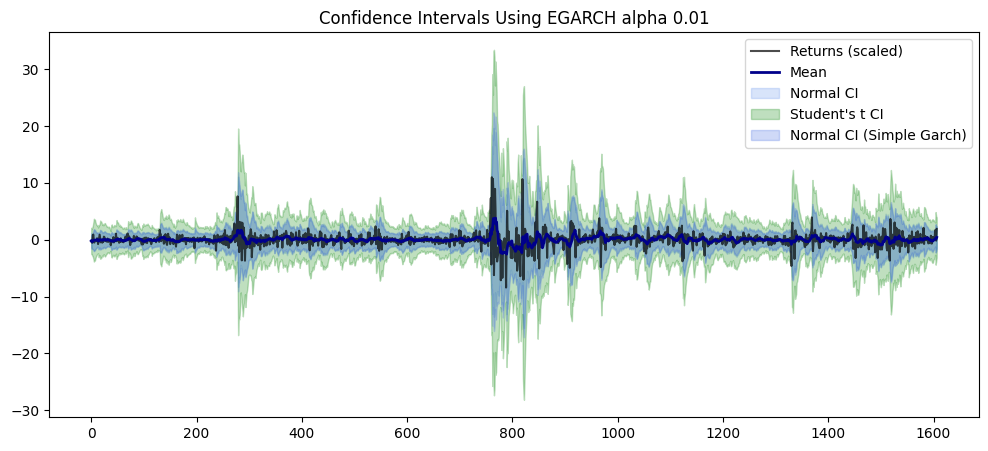

In [7]:
#Approach using rolling mean (for the "window" number of days)
rolling_mean = np.convolve(log_returns_usd_scaled, np.ones(window)/window, mode='valid')

#remove the beggining of the arrays
trim_start = window - 1 
log_returns_usd_scaled_trimmed = log_returns_usd_scaled[trim_start:]
conditional_volatility_egarch_trimmed = conditional_volatility_egarch[trim_start:]
conditional_volatility_garch_trimmed = conditional_volatility_garch[trim_start:]
conditional_volatility_tegarch_trimmed = conditional_volatility_tegarch[trim_start:]

# Confidence intervals for Normal distribution
z = stats.norm.ppf(1 - alpha / 2)
ci_upper_norm = rolling_mean + z * conditional_volatility_egarch_trimmed
ci_lower_norm = rolling_mean - z * conditional_volatility_egarch_trimmed

# Confidence intervals for Student's t distribution
# Degrees of freedom can be set as per your model, here assumed 10 for example
df = parameters_tegarch.nu
t = stats.t.ppf(1 - alpha / 2, df)
ci_upper_t = rolling_mean + t * conditional_volatility_tegarch_trimmed
ci_lower_t = rolling_mean - t * conditional_volatility_tegarch_trimmed

#confidence intervals using Normal distribution for the case of simpel GARCH
z = stats.norm.ppf(1 - alpha / 2)
ci_upper_simple = rolling_mean + z * conditional_volatility_garch_trimmed
ci_lower_simple = rolling_mean - z * conditional_volatility_garch_trimmed

# Plot
plt.figure(figsize=(12, 5))
plt.plot(log_returns_usd_scaled_trimmed, color='black', alpha=0.7, label='Returns (scaled)')
plt.plot(rolling_mean, color='darkblue', label=f'Mean', linewidth=2)
plt.fill_between(np.arange(len(log_returns_usd_scaled_trimmed)), ci_lower_norm, ci_upper_norm, color='cornflowerblue', alpha=0.25, label='Normal CI')
plt.fill_between(np.arange(len(log_returns_usd_scaled_trimmed)), ci_lower_t, ci_upper_t, color='green', alpha=0.25, label="Student's t CI")
plt.fill_between(np.arange(len(log_returns_usd_scaled_trimmed)), ci_lower_simple, ci_upper_simple, color='royalblue', alpha=0.25, label='Normal CI (Simple Garch)')
plt.title(f'Confidence Intervals Using EGARCH alpha {alpha}')
plt.legend()
plt.show()

In [8]:
# Create figure
fig = go.Figure()

# Add the returns line (scaled)
fig.add_trace(go.Scatter(
    x=np.arange(len(log_returns_usd_scaled_trimmed)),
    y=log_returns_usd_scaled_trimmed,
    mode='lines',
    name='Returns (scaled)',
    line=dict(color='black', width=1),
    opacity=0.7
))

# Add the mean line
fig.add_trace(go.Scatter(
    x=np.arange(len(rolling_mean)),
    y=rolling_mean,
    mode='lines',
    name=f'Mean (Aggregate Mean) = {rolling_mean[0]:.4f}',
    line=dict(color='darkblue', width=2)
))

# Add Normal CI (filled area)
fig.add_trace(go.Scatter(
    x=np.arange(len(log_returns_usd_scaled_trimmed)),
    y=ci_upper_norm,
    mode='lines',
    line=dict(width=0),
    showlegend=False,
    hoverinfo='skip'
))
fig.add_trace(go.Scatter(
    x=np.arange(len(log_returns_usd_scaled_trimmed)),
    y=ci_lower_norm,
    mode='lines',
    line=dict(width=0),
    fillcolor='rgba(100, 149, 237, 0.25)',  # cornflowerblue with alpha
    fill='tonexty',
    name='Normal CI',
    hoverinfo='skip'
))

# Add Student's t CI (filled area)
fig.add_trace(go.Scatter(
    x=np.arange(len(log_returns_usd_scaled_trimmed)),
    y=ci_upper_t,
    mode='lines',
    line=dict(width=0),
    showlegend=False,
    hoverinfo='skip'
))
fig.add_trace(go.Scatter(
    x=np.arange(len(log_returns_usd_scaled_trimmed)),
    y=ci_lower_t,
    mode='lines',
    line=dict(width=0),
    fillcolor='rgba(0, 128, 0, 0.25)',  # green with alpha
    fill='tonexty',
    name="Student's t CI",
    hoverinfo='skip'
))

# Add Normal CI (Simple Garch) (filled area)
fig.add_trace(go.Scatter(
    x=np.arange(len(log_returns_usd_scaled_trimmed)),
    y=ci_upper_simple,
    mode='lines',
    line=dict(width=0),
    showlegend=False,
    hoverinfo='skip'
))
fig.add_trace(go.Scatter(
    x=np.arange(len(log_returns_usd_scaled_trimmed)),
    y=ci_lower_simple,
    mode='lines',
    line=dict(width=0),
    fillcolor='rgba(65, 105, 225, 0.25)',  # royalblue with alpha
    fill='tonexty',
    name='Normal CI (Simple Garch)',
    hoverinfo='skip'
))

# Update layout
fig.update_layout(
    title=f'Confidence Intervals Using EGARCH alpha {alpha}',
    width=1200,
    height=500,
    hovermode='x unified',
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    )
)

fig.show()


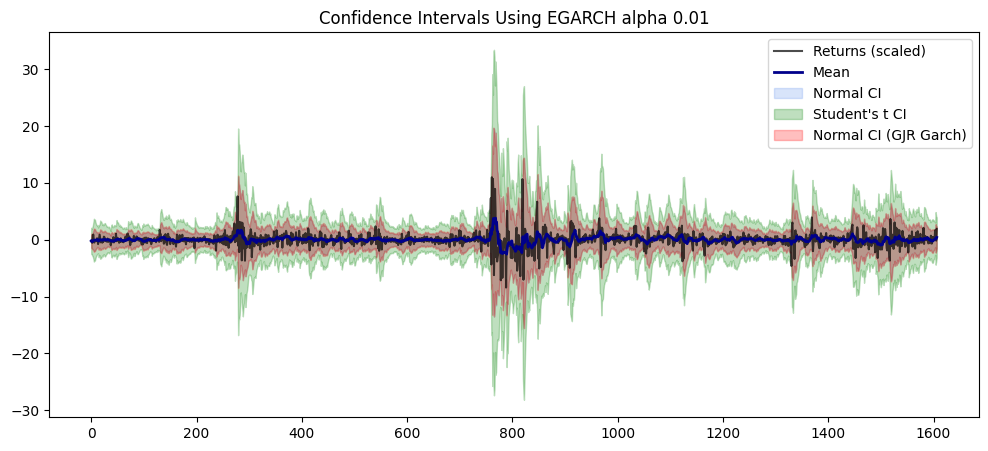

In [15]:
#Approach using rolling mean (for the "window" number of days)
rolling_mean = np.convolve(log_returns_usd_scaled, np.ones(window)/window, mode='valid')

#remove the beggining of the arrays
trim_start = window - 1 
log_returns_usd_scaled_trimmed = log_returns_usd_scaled[trim_start:]
conditional_volatility_egarch_trimmed = conditional_volatility_egarch[trim_start:]
conditional_volatility_gjr_trimed = conditional_volatility_gjr[trim_start:]
conditional_volatility_tegarch_trimmed = conditional_volatility_tegarch[trim_start:]

# Confidence intervals for Normal distribution
z = stats.norm.ppf(1 - alpha / 2)
ci_upper_norm = rolling_mean + z * conditional_volatility_egarch_trimmed
ci_lower_norm = rolling_mean - z * conditional_volatility_egarch_trimmed

# Confidence intervals for Student's t distribution
# Degrees of freedom can be set as per your model, here assumed 10 for example
df = parameters_tegarch.nu
t = stats.t.ppf(1 - alpha / 2, df)
ci_upper_t = rolling_mean + t * conditional_volatility_tegarch_trimmed
ci_lower_t = rolling_mean - t * conditional_volatility_tegarch_trimmed

#confidence intervals using Normal distribution for the case of simpel GARCH
z = stats.norm.ppf(1 - alpha / 2)
ci_upper_gjr = rolling_mean + z * conditional_volatility_gjr_trimed
ci_lower_gjr = rolling_mean - z * conditional_volatility_gjr_trimed

# Plot
plt.figure(figsize=(12, 5))
plt.plot(log_returns_usd_scaled_trimmed, color='black', alpha=0.7, label='Returns (scaled)')
plt.plot(rolling_mean, color='darkblue', label=f'Mean', linewidth=2)
plt.fill_between(np.arange(len(log_returns_usd_scaled_trimmed)), ci_lower_norm, ci_upper_norm, color='cornflowerblue', alpha=0.25, label='Normal CI')
plt.fill_between(np.arange(len(log_returns_usd_scaled_trimmed)), ci_lower_t, ci_upper_t, color='green', alpha=0.25, label="Student's t CI")
plt.fill_between(np.arange(len(log_returns_usd_scaled_trimmed)), ci_lower_gjr, ci_upper_gjr, color='red', alpha=0.25, label='Normal CI (GJR Garch)')
plt.title(f'Confidence Intervals Using EGARCH alpha {alpha}')
plt.legend()
plt.show()

In [13]:
# Create figure
fig = go.Figure()

# Add the returns line (scaled)
fig.add_trace(go.Scatter(
    x=np.arange(len(log_returns_usd_scaled_trimmed)),
    y=log_returns_usd_scaled_trimmed,
    mode='lines',
    name='Returns (scaled)',
    line=dict(color='black', width=1),
    opacity=0.7
))

# Add the mean line
fig.add_trace(go.Scatter(
    x=np.arange(len(rolling_mean)),
    y=rolling_mean,
    mode='lines',
    name=f'Mean (Aggregate Mean) = {rolling_mean[0]:.4f}',
    line=dict(color='darkblue', width=2)
))

# Add Normal CI (filled area)
fig.add_trace(go.Scatter(
    x=np.arange(len(log_returns_usd_scaled_trimmed)),
    y=ci_upper_norm,
    mode='lines',
    line=dict(width=0),
    showlegend=False,
    hoverinfo='skip'
))
fig.add_trace(go.Scatter(
    x=np.arange(len(log_returns_usd_scaled_trimmed)),
    y=ci_lower_norm,
    mode='lines',
    line=dict(width=0),
    fillcolor='rgba(100, 149, 237, 0.25)',  # cornflowerblue with alpha
    fill='tonexty',
    name='Normal CI',
    hoverinfo='skip'
))

# Add Student's t CI (filled area)
fig.add_trace(go.Scatter(
    x=np.arange(len(log_returns_usd_scaled_trimmed)),
    y=ci_upper_t,
    mode='lines',
    line=dict(width=0),
    showlegend=False,
    hoverinfo='skip'
))
fig.add_trace(go.Scatter(
    x=np.arange(len(log_returns_usd_scaled_trimmed)),
    y=ci_lower_t,
    mode='lines',
    line=dict(width=0),
    fillcolor='rgba(0, 128, 0, 0.25)',  # green with alpha
    fill='tonexty',
    name="Student's t CI",
    hoverinfo='skip'
))

# Add Normal CI (Simple Garch) (filled area)
fig.add_trace(go.Scatter(
    x=np.arange(len(log_returns_usd_scaled_trimmed)),
    y=ci_upper_gjr,
    mode='lines',
    line=dict(width=0),
    showlegend=False,
    hoverinfo='skip'
))
fig.add_trace(go.Scatter(
    x=np.arange(len(log_returns_usd_scaled_trimmed)),
    y=ci_lower_gjr,
    mode='lines',
    line=dict(width=0),
    fillcolor='rgba(65, 105, 225, 0.25)',  # royalblue with alpha
    fill='tonexty',
    name='Normal CI (Simple Garch)',
    hoverinfo='skip'
))

# Update layout
fig.update_layout(
    title=f'Confidence Intervals Using EGARCH alpha {alpha}',
    width=1200,
    height=500,
    hovermode='x unified',
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    )
)

fig.show()


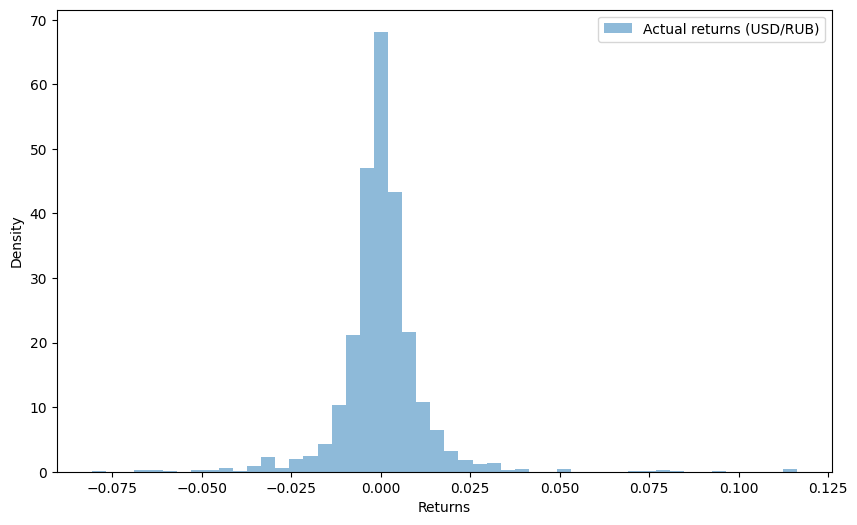

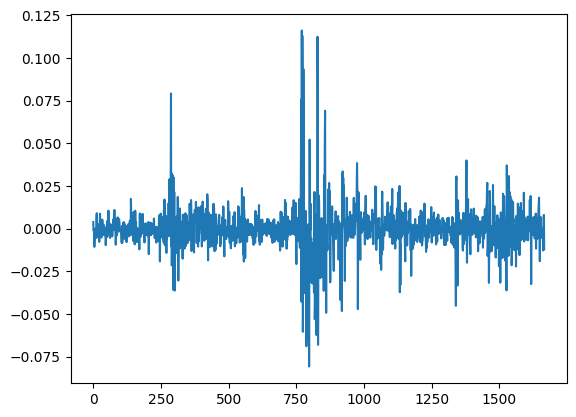

In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot histograms of the terminal returns distribution for 15 days forecasr
ax.hist(original_returns, bins=50, density=True, alpha=0.5, label='Actual returns (USD/RUB)')

# Add labels and title
ax.set_xlabel('Returns')
ax.set_ylabel('Density')
ax.legend()
plt.show()

plt.plot(original_returns)
plt.show()